In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv("insurance.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicates before removal: 1
Duplicates after removal: 0
New dataset shape: (1337, 7)


In [14]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [15]:
X_encoded = pd.get_dummies(X, columns=["sex", "smoker", "region"], drop_first=True)

print("Encoded Features:")
print(X_encoded.head())

print("\nNew Shape:", X_encoded.shape)

Encoded Features:
   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

New Shape: (1337, 8)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1069
Testing samples: 268


In [17]:
linear_model = LinearRegression()

ridge_model = Ridge(alpha=1.0)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [18]:
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [19]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "R2 Score": r2
    }

results = []

results.append(evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
))

results.append(evaluate_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
))

results.append(evaluate_model(
    "Random Forest Regressor",
    y_test,
    y_pred_rf
))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,R2 Score
0,Linear Regression,4177.045561,3.547802e+07,0.806929
1,Ridge Regression,4194.009577,3.565688e+07,0.805955
2,Random Forest Regressor,2637.994548,2.211300e+07,0.879661


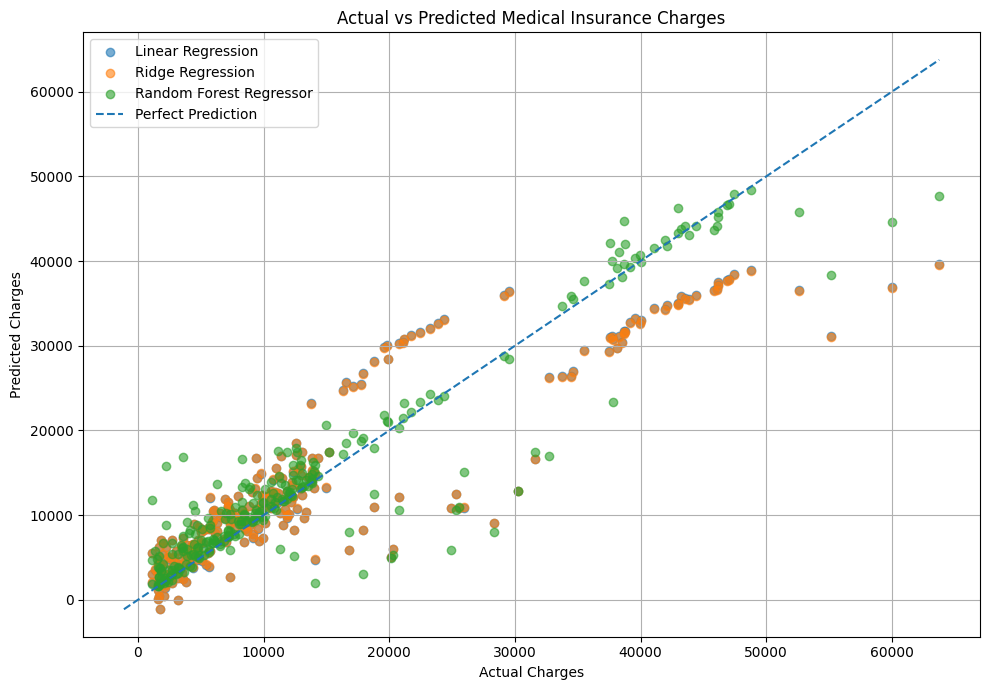

In [20]:
plt.figure(figsize=(10, 7))

plt.scatter(y_test, y_pred_linear, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_ridge, alpha=0.6, label="Ridge Regression")
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest Regressor")

min_value = min(y_test.min(), y_pred_linear.min(), y_pred_ridge.min(), y_pred_rf.min())
max_value = max(y_test.max(), y_pred_linear.max(), y_pred_ridge.max(), y_pred_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

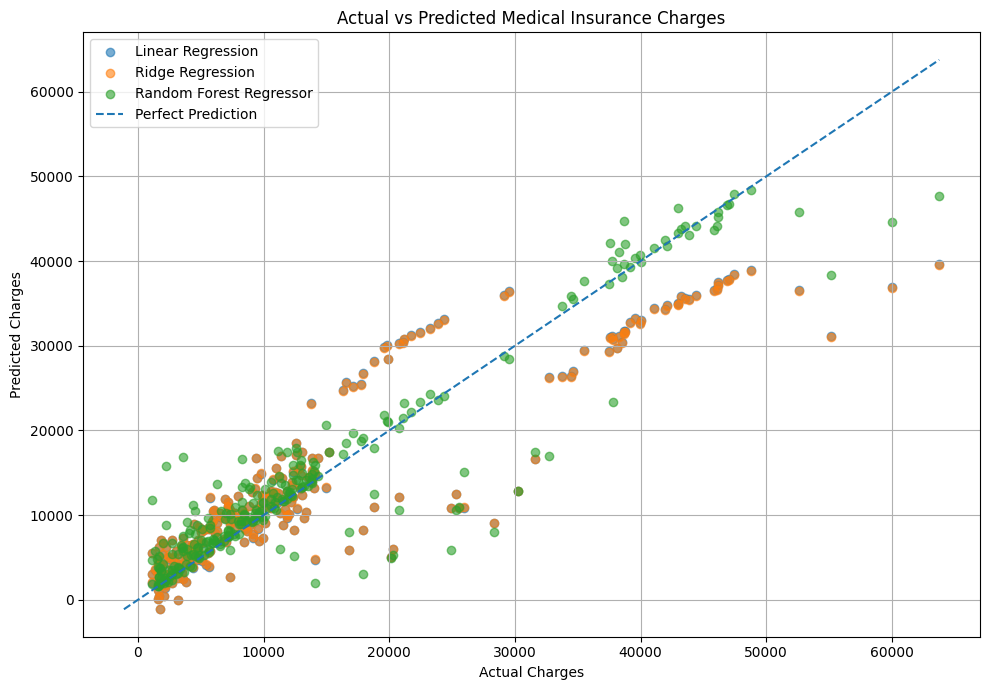

In [21]:
plt.figure(figsize=(10, 7))

plt.scatter(y_test, y_pred_linear, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_ridge, alpha=0.6, label="Ridge Regression")
plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest Regressor")

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("Model Performance Comparison:")
results_df

Model Performance Comparison:


,Model,MAE,MSE,R2 Score
2,Random Forest Regressor,2637.994548,2.211300e+07,0.879661
0,Linear Regression,4177.045561,3.547802e+07,0.806929
1,Ridge Regression,4194.009577,3.565688e+07,0.805955


In [23]:
import os

print("PNG file exists:", os.path.exists("actual_vs_predicted.png"))

if os.path.exists("actual_vs_predicted.png"):
    print("File size:", os.path.getsize("actual_vs_predicted.png"), "bytes")

PNG file exists: True
File size: 557615 bytes


In [24]:
from google.colab import files

files.download("actual_vs_predicted.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Key Findngs

* Three regression models were trained and evaluated.
* Random Forest performed best with an R² of 0.8797
* It achieved the lowest MAE 2637.99 and MSE 22.11 million.
* Overall, Random Forest Regressor was the best model for predicting insurance charges.
